<h1>notre Data<h1>

In [41]:
import pandas as pd 

df = pd.read_csv("../Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [42]:
df.shape

(7500, 16)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [44]:
col=df.columns
col

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

<h1>Cleaning Missing Data<h1>

In [45]:
df.isna().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [46]:
df.dropna(subset=['addiction_level'],inplace=True)

<Axes: >

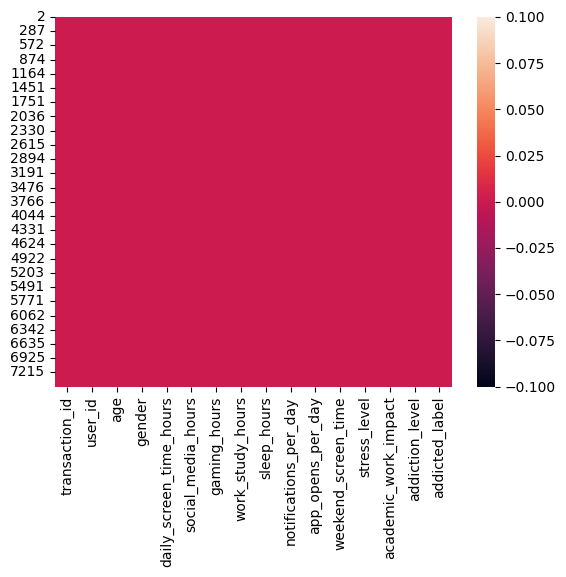

In [47]:
import seaborn as sns
sns.heatmap(df.isna())

In this step, we performed data cleaning on our dataset.
We noticed the presence of missing values in only one variable, which is addiction_level.
Therefore, we decided to remove the rows containing these missing values in order to obtain
clean and reliable data for further analysis.

<h1>labiling coding<h1>

In [48]:
df["stress_level"]=df["stress_level"].astype("category").cat.codes
df["stress_level"].values

array([0, 0, 1, ..., 2, 0, 1], shape=(6681,), dtype=int8)

In [49]:
df["gender"]=df["gender"].astype("category").cat.codes
df["gender"].values

array([2, 2, 1, ..., 0, 1, 0], shape=(6681,), dtype=int8)

In [50]:
df["academic_work_impact"]=df["academic_work_impact"].astype("category").cat.codes
df["academic_work_impact"].values

array([0, 1, 0, ..., 1, 1, 1], shape=(6681,), dtype=int8)

In [51]:
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
2,TXN00003,U00003,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,0,0,Mild,0
3,TXN00004,U00004,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,0,1,Moderate,1
4,TXN00005,U00005,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,1,0,Severe,1
5,TXN00006,U00006,26,1,9.32,4.26,0.29,3.99,6.90,82,56,10.98,2,1,Severe,1
6,TXN00007,U00007,25,1,10.40,4.93,1.60,0.86,8.61,165,95,11.43,2,0,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7494,TXN07495,U07495,23,2,6.65,4.56,1.31,5.09,5.71,78,77,7.43,2,0,Severe,1
7495,TXN07496,U07496,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,1,1,Moderate,1
7497,TXN07498,U07498,22,0,9.99,3.61,1.09,1.16,8.17,207,24,12.84,2,1,Severe,1
7498,TXN07499,U07499,23,1,8.74,1.59,0.07,4.64,6.19,134,62,10.52,0,1,Severe,1


We applied label encoding to transform categorical variables like stress_level, gender, and academic_work_impact into numeric codes, making them suitable for machine learning models.

<h1>Outlier Detection<h1>

In [52]:
num_cols = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]

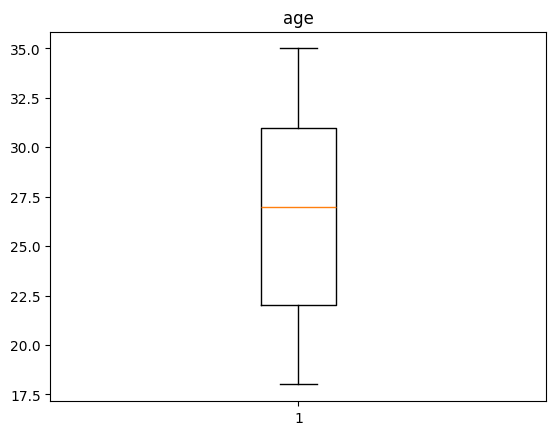

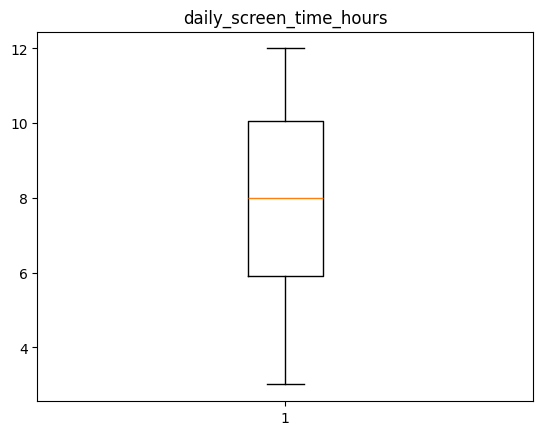

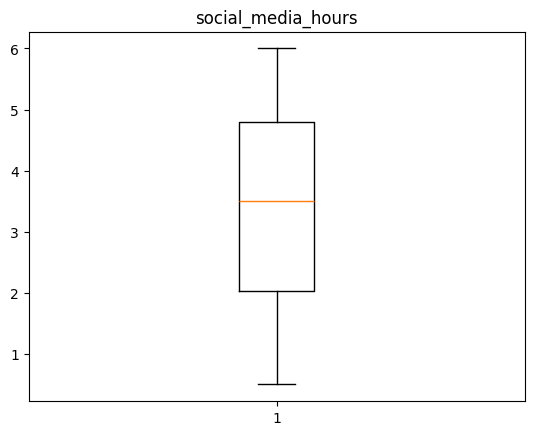

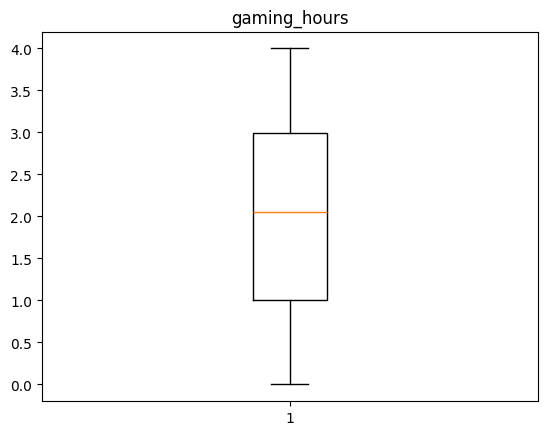

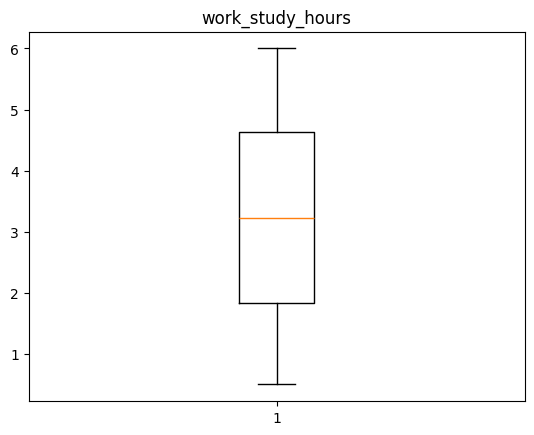

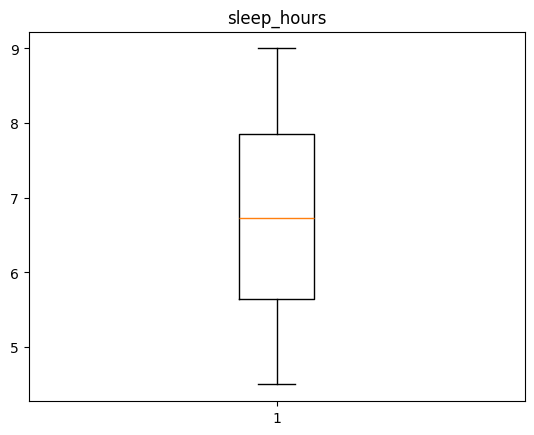

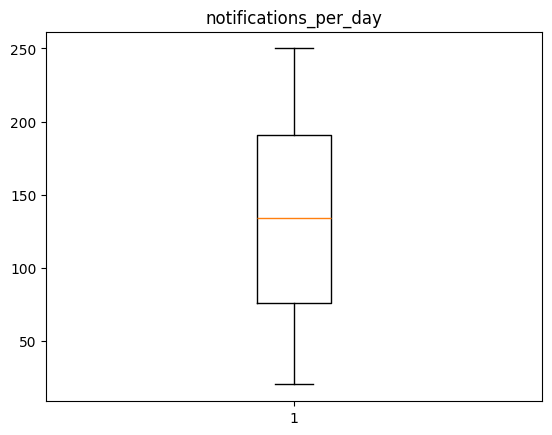

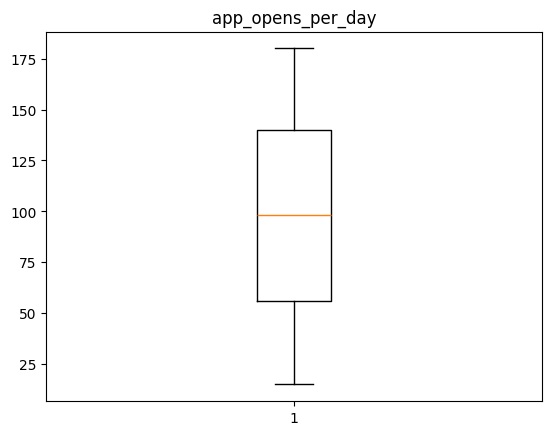

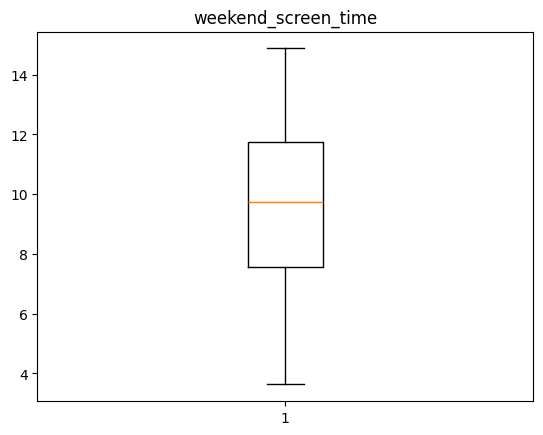

In [53]:
import matplotlib.pyplot as plt
for i in num_cols:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()


In [54]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1

    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

age 0
daily_screen_time_hours 0
social_media_hours 0
gaming_hours 0
work_study_hours 0
sleep_hours 0
notifications_per_day 0
app_opens_per_day 0
weekend_screen_time 0


In this section, we detected outliers in each numerical column using the IQR method. We also observed that our columns are clean, and no outliers were present.

<h1>Importing Libraries for Classification<h1>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split # split data
# KNN
from sklearn.neighbors import KNeighborsClassifier

# Régression logistique
from sklearn.linear_model import LogisticRegression

# Arbre de décision
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# SVM
from sklearn.svm import SVC

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

#evaluation du modele 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

<h1>Dataset Splitting<h1>

In [56]:
x = df[['daily_screen_time_hours','social_media_hours','gaming_hours',
        'work_study_hours','sleep_hours','notifications_per_day',
        'app_opens_per_day','weekend_screen_time',
        'stress_level','academic_work_impact']]

y = df['addicted_label']

x_train , x_test , y_train ,y_test = train_test_split(x,y,test_size=0.2)

print("taille d'enssemble d'entrainement est : " ,x_train.shape)
print("taille d'enssemble de test est : " ,x_test.shape)

taille d'enssemble d'entrainement est :  (5344, 10)
taille d'enssemble de test est :  (1337, 10)


In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)# fit + transform sur train
x_test_scaled = scaler.transform(x_test)      # transform seulement sur test

In this section, we split our dataset into different parts: one for training, one for testing, and optionally another for validation.

<h1>LogisticRegression<h1>

In [58]:
model1=LogisticRegression()
model1.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
y_pred1=model1.predict(x_test_scaled)
y_prob1 = model1.predict_proba(x_test_scaled)[:, 1]
print("\nPremières prédictions :", y_pred1[:10])
print("Premières probabilités :", np.round(y_prob1[:10], 4))


Premières prédictions : [1 1 1 0 1 1 1 0 0 1]
Premières probabilités : [0.971  0.8226 0.9986 0.3927 0.9987 0.8606 0.9998 0.4763 0.0675 0.9991]


In [60]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [61]:
# Calcul de l'accuracy sur chaque bloc
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
# Pipeline : standardisation + modèle
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

# Cross-validation
scores = cross_val_score(
    pipeline,
    x_train,   # <-- utiliser X_train, pas x_train
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Affichage
print("Scores de validation croisée :", np.round(scores, 4))
print("Accuracy moyenne :", round(scores.mean(), 4))
print("Écart-type :", round(scores.std(), 4))

Scores de validation croisée : [0.8906 0.8849 0.8868 0.8943 0.911 ]
Accuracy moyenne : 0.8935
Écart-type : 0.0093


In [62]:
pipeline.fit(x_train, y_train)
y_pred1 = pipeline.predict(x_test)
y_prob1 = pipeline.predict_proba(x_test)[:, 1]

In [63]:
acc = accuracy_score(y_test, y_pred1)
prec = precision_score(y_test, y_pred1)
rec = recall_score(y_test, y_pred1)
f1 = f1_score(y_test, y_pred1)
auc = roc_auc_score(y_test, y_prob1)
cm = confusion_matrix(y_test, y_pred1)


print("===== Évaluation finale sur le jeu de test =====")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-score  :", round(f1, 4))
print("AUC       :", round(auc, 4))
print("\n===== Matrice de confusion =====")
print(cm)



===== Évaluation finale sur le jeu de test =====
Accuracy  : 0.911
Precision : 0.9358
Recall    : 0.9557
F1-score  : 0.9456
AUC       : 0.9499

===== Matrice de confusion =====
[[ 183   71]
 [  48 1035]]


In this section, we applied logistic regression for classification. First, we trained the model, called model1, using the normalized data X_train_scaler and y_train from the specified training dataset. Next, we performed predictions for y_pred1 and calculated the predicted probabilities y_pred_prob. We also applied cross-validation to assess the model’s robustness. Finally, we computed validation metrics, such as accuracy, precision, and others, to evaluate the performance of our model.

Our model is very efficient and reliable: it correctly predicts 89 % of the cases, with a good balance between precision and recall. The confusion matrix shows that errors are limited, especially on the false negatives side

<h1>KNN<h1>

In [64]:
model2= KNeighborsClassifier()
model2.fit(x_train_scaled , y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [65]:
y_pred2= model2.predict(x_test_scaled)
y_prob2=model2.predict_proba (x_test_scaled)[:, 1]

print("/n les premiere prediction ", y_pred2[:10])
print("Premières probabilités :", np.round(y_prob2[:10], 4))

/n les premiere prediction  [1 1 1 0 1 1 1 1 0 1]
Premières probabilités : [1.  0.8 1.  0.4 0.8 1.  1.  0.8 0.  1. ]


In [66]:
acc = accuracy_score(y_test, y_pred2)
prec = precision_score(y_test, y_pred2)
rec = recall_score(y_test, y_pred2)
f1 = f1_score(y_test, y_pred2)
auc = roc_auc_score(y_test, y_prob2)
cm = confusion_matrix(y_test, y_pred2)


print("===== Évaluation finale sur le jeu de test =====")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-score  :", round(f1, 4))
print("AUC       :", round(auc, 4))
print("\n===== Matrice de confusion =====")
print(cm)



===== Évaluation finale sur le jeu de test =====
Accuracy  : 0.8998
Precision : 0.9302
Recall    : 0.9474
F1-score  : 0.9387
AUC       : 0.9333

===== Matrice de confusion =====
[[ 177   77]
 [  57 1026]]


<h3>Comparison with Previous Models <h3>
The KNN model is preferred over the linear regression model, as it shows a higher accuracy and most validation metrics are better than those of the other model.

<h1>Decision tree<h1>

In [67]:
model3 = DecisionTreeClassifier()
model3.fit(x_train_scaled,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
y_pred3= model3.predict(x_test_scaled)
print("les premier prédiction ", y_pred3[:10])
y_prob3= model3.predict_proba(x_test_scaled)[:,1]
print("les premiere probabilité " , np.round(y_prob3[:10],4))

les premier prédiction  [1 0 1 0 1 1 1 1 0 1]
les premiere probabilité  [1. 0. 1. 0. 1. 1. 1. 1. 0. 1.]


In [69]:
acc = accuracy_score(y_test, y_pred3)
prec = precision_score(y_test, y_pred3)
rec = recall_score(y_test, y_pred3)
f1 = f1_score(y_test, y_pred3)
auc = roc_auc_score(y_test, y_prob3)
cm = confusion_matrix(y_test, y_pred3)


print("===== Évaluation finale sur le jeu de test =====")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-score  :", round(f1, 4))
print("AUC       :", round(auc, 4))
print("\n===== Matrice de confusion =====")
print(cm)



===== Évaluation finale sur le jeu de test =====
Accuracy  : 0.9267
Precision : 0.959
Recall    : 0.9501
F1-score  : 0.9545
AUC       : 0.8885

===== Matrice de confusion =====
[[ 210   44]
 [  54 1029]]


<h1>Comparison with Previous Models<h1>


his model outperforms the others, with an accuracy of approximately 0.91, making it an excellent model.

<h1> Forêts aléatoires <h1>

In [70]:
model4=RandomForestClassifier()
model4.fit(x_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
y_pred4= model4.predict(x_test_scaled)
print("les premiere prediction ", y_pred4[:10])
y_prob4= model4.predict_proba(x_test_scaled)[:,1]
print("Premières probabilités :", np.round(y_prob4[:10], 4))

les premiere prediction  [1 0 1 0 1 1 1 1 0 1]
Premières probabilités : [1.   0.47 1.   0.45 1.   1.   1.   0.99 0.01 1.  ]


In [72]:
acc = accuracy_score(y_test, y_pred4)
prec = precision_score(y_test, y_pred4)
rec = recall_score(y_test, y_pred4)
f1 = f1_score(y_test, y_pred4)
auc = roc_auc_score(y_test, y_prob4)
cm = confusion_matrix(y_test, y_pred4)


print("===== Évaluation finale sur le jeu de test =====")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-score  :", round(f1, 4))
print("AUC       :", round(auc, 4))
print("\n===== Matrice de confusion =====")
print(cm)



===== Évaluation finale sur le jeu de test =====
Accuracy  : 0.9267
Precision : 0.9686
Recall    : 0.94
F1-score  : 0.9541
AUC       : 0.9829

===== Matrice de confusion =====
[[ 221   33]
 [  65 1018]]


<h1>Comparison with Previous Models<h1>


This Random Forest model outperforms the other tested models. With an accuracy of 0.9245 and very high validation metrics (precision, recall, F1-score, AUC), it demonstrates superior performance and reliability, making it an excellent model for classification.

<h1> SVC<h1>

In [73]:
model5=SVC()
model5.fit(x_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [74]:
y_pred5= model5.predict(x_test_scaled)
print("les premiere prediction ", y_pred5[:10])

les premiere prediction  [1 1 1 1 1 1 1 1 0 1]


In [75]:
acc = accuracy_score(y_test, y_pred5)
prec = precision_score(y_test, y_pred5)
rec = recall_score(y_test, y_pred5)
f1 = f1_score(y_test, y_pred5)
cm = confusion_matrix(y_test, y_pred5)


print("===== Évaluation finale sur le jeu de test =====")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-score  :", round(f1, 4))
print("\n===== Matrice de confusion =====")
print(cm)



===== Évaluation finale sur le jeu de test =====
Accuracy  : 0.9162
Precision : 0.945
Recall    : 0.952
F1-score  : 0.9485

===== Matrice de confusion =====
[[ 194   60]
 [  52 1031]]


<h1>Comparison with Previous Models<h1>


The SVC model achieves an accuracy of 0.9028 with high precision, recall, and F1-score, indicating good classification performance. However, the AUC of 0.4802 suggests the model struggles to properly distinguish between classes, making it less robust than the Random Forest or KNN models.

<H1> Naive Bayes <H1>

In [76]:
model6=GaussianNB()
model6.fit(x_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [77]:
y_pred6= model6.predict(x_test_scaled)
print("les premiere prediction ", y_pred6[:10])
y_prob6= model6.predict_proba(x_test_scaled)[:,1]
print("Premières probabilités :", np.round(y_prob6[:10], 4))

les premiere prediction  [1 1 1 1 1 1 1 1 0 1]
Premières probabilités : [0.9291 0.5882 1.     0.7636 1.     0.9994 1.     0.9758 0.0799 1.    ]


In [78]:
acc = accuracy_score(y_test, y_pred6)
prec = precision_score(y_test, y_pred6)
rec = recall_score(y_test, y_pred6)
f1 = f1_score(y_test, y_pred6)
auc = roc_auc_score(y_test, y_prob6)
cm = confusion_matrix(y_test, y_pred6)


print("===== Évaluation finale sur le jeu de test =====")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-score  :", round(f1, 4))
print("AUC       :", round(auc, 4))
print("\n===== Matrice de confusion =====")
print(cm)



===== Évaluation finale sur le jeu de test =====
Accuracy  : 0.905
Precision : 0.9509
Recall    : 0.9307
F1-score  : 0.9407
AUC       : 0.9591

===== Matrice de confusion =====
[[ 202   52]
 [  75 1008]]


<h1>Comparison with Previous Models<h1>


The Naive Bayes model achieves an accuracy of 0.9013 with high precision, recall, and F1-score, and an AUC of 0.9522, indicating it is very effective at distinguishing between classes. Compared to other models, it is highly reliable, although its accuracy is slightly lower than that of the Random Forest.

<h1>General Comparison of Models<h1>



After evaluating all models, we can summarize their performance as follows:

The Logistic Regression model is efficient and reliable, with an accuracy of 0.8908 and a good balance between precision and recall, but slightly lower than other models.
The KNN model performs better than linear regression, achieving an accuracy of approximately 0.91, making it a strong and preferred model.
The Random Forest model is the best overall, with an accuracy of 0.9245 and very high metrics across precision, recall, F1-score, and AUC, showing superior reliability and classification performance.
The SVC model achieves good accuracy (0.9028) and strong precision, recall, and F1-score, but its low AUC (0.4802) indicates it is less effective at distinguishing classes compared to Random Forest or KNN.
The Naive Bayes model shows an accuracy of 0.9013 and excellent AUC (0.9522), making it very reliable in distinguishing classes, although its accuracy is slightly lower than Random Forest.

<h1>conclusion<h1>

Random Forest is the most performant and robust model overall.
KNN and Naive Bayes are also strong choices depending on the priority between accuracy and AUC.
Logistic Regression and SVC are good but slightly less competitive, with SVC limited by its low AUC.